In [9]:
from chardet import detect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

def get_encoding_type(file: str):
    with open(file, 'rb') as f:
        rawdata = f.read()
    return detect(rawdata)['encoding']

timeseries_file = './142h_ka_as_2025_20260403-223008.csv'
ts_data = pd.read_csv(filepath_or_buffer=timeseries_file, sep='\t', encoding=get_encoding_type(file=timeseries_file))

mun = ts_data.pivot(index='Region', columns='Information', values='2024').reset_index()

conn = sqlite3.connect("municipalities.db")
mun.to_sql("municipalities", conn, if_exists="replace", index=False)



308

In [11]:
query1 = """
SELECT Region, Population 
FROM municipalities 
WHERE Population IS NOT NULL
ORDER BY CAST(Population AS REAL) DESC 
LIMIT 10
"""
result1 = pd.read_sql_query(query1, conn)
print("Top 10 Most Populated municipalities")
print(result1.to_string(index=False))
print("Big southern cities fare well on this query.")

Top 10 Most Populated municipalities
   Region Population
 Helsinki     684018
    Espoo     320931
  Tampere     260180
   Vantaa     251269
     Oulu     216152
    Turku     206073
Jyväskylä     149194
   Kuopio     125666
    Lahti     121337
     Pori      83305
Big southern cities fare well on this query.


In [13]:
query2 = """
SELECT Region, "Share of unemployed persons in the labour force, %"
FROM municipalities
WHERE "Share of unemployed persons in the labour force, %" IS NOT NULL
ORDER BY CAST("Share of unemployed persons in the labour force, %" AS REAL) DESC
LIMIT 10
"""
result2 = pd.read_sql_query(query2, conn)
print("Top 10 Municipalities with Highest Unemployment Rate")
print(result2.to_string(index=False))
print("Small municipalities show highest unemployment.")

Top 10 Municipalities with Highest Unemployment Rate
     Region Share of unemployed persons in the labour force, %
   Puolanka                                               21.0
      Juuka                                               20.7
   Rääkkylä                                               19.5
  Outokumpu                                               19.1
 Pudasjärvi                                               19.0
  Ilomantsi                                               18.6
     Lieksa                                               18.6
      Kitee                                               18.5
Taivalkoski                                               18.5
     Imatra                                               18.2
Small municipalities show highest unemployment.


In [18]:
query3 = """
SELECT Region, "Employment rate of persons aged 20 to 64, %"
FROM municipalities
WHERE "Employment rate of persons aged 20 to 64, %" IS NOT NULL
ORDER BY CAST("Employment rate of persons aged 20 to 64, %" AS REAL) DESC
LIMIT 10
"""
result3 = pd.read_sql_query(query3, conn)
print("Top 10 Municipalities by Employment Rate")
print(result3.to_string(index=False))
print("Highest employment rates in municipalities.")

Top 10 Municipalities by Employment Rate
    Region Employment rate of persons aged 20 to 64, %
  Kumlinge                                        88.6
    Jomala                                        88.0
  Korsholm                                        87.9
    Larsmo                                        86.8
 Pedersöre                                        86.7
     Malax                                        86.5
     Rusko                                        86.1
Hammarland                                        85.9
  Finström                                        85.4
    Närpes                                        85.4
Highest employment rates in municipalities.


In [20]:
rovaniemi = ts_data[ts_data['Region'] == 'Rovaniemi']

pop_row = rovaniemi[rovaniemi['Information'] == 'Population']
edu_row = rovaniemi[rovaniemi['Information'] == 'Persons with tertiary level qualifications, share of persons aged 15 or over, %']

year_cols = [col for col in ts_data.columns if col not in ['Region', 'Information']]

pop_values = pd.to_numeric(pop_row[year_cols].values.flatten(), errors='coerce')
edu_values = pd.to_numeric(edu_row[year_cols].values.flatten(), errors='coerce')

correlation = pd.Series(pop_values).corr(pd.Series(edu_values))

print(f"Pearson correlation: {correlation:.3f}")
print(f"\nAs Rovaniemi's population grows, tertiary education rates increase consistently.")

Pearson correlation: 0.981

As Rovaniemi's population grows, tertiary education rates increase consistently.


## Matplotlib visualizations

Large cities and small municipalities have lower unemployment variance. mid size municipalities show wider range.


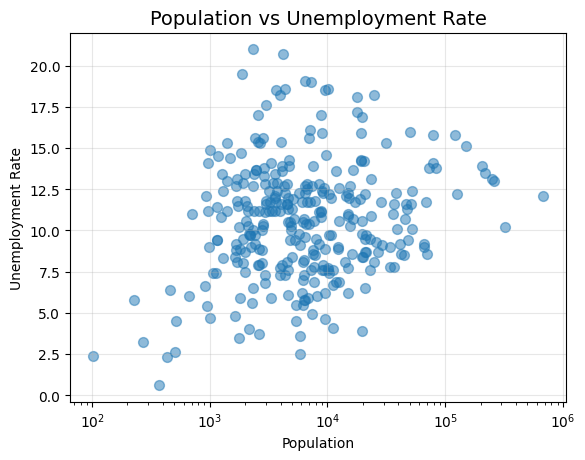

In [22]:
pop = pd.to_numeric(mun['Population'], errors='coerce')
unemp = pd.to_numeric(mun['Share of unemployed persons in the labour force, %'], errors='coerce')

plt.scatter(pop, unemp, alpha=0.5, s=50)
plt.xlabel('Population')
plt.ylabel('Unemployment Rate')
plt.title('Population vs Unemployment Rate', fontsize=14)
plt.xscale('log')
plt.grid(True, alpha=0.3)

print("Large cities and small municipalities have lower unemployment variance. mid size municipalities show wider range.")

Distribution is roughly normal with most municipalities around 75% employment rate.


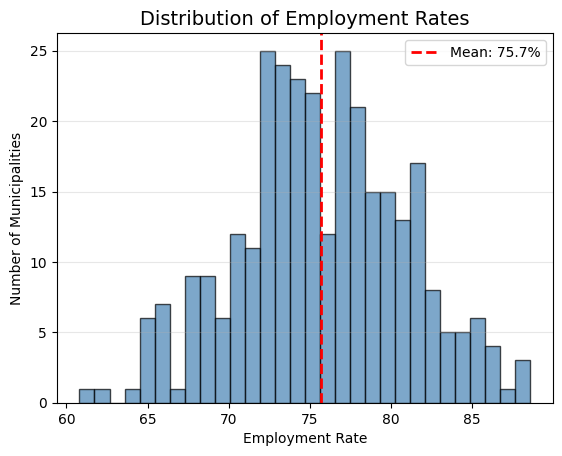

In [24]:
emp_rate = pd.to_numeric(mun['Employment rate of persons aged 20 to 64, %'], errors='coerce')

plt.hist(emp_rate.dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(emp_rate.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {emp_rate.mean():.1f}%")
plt.xlabel('Employment Rate')
plt.ylabel('Number of Municipalities')
plt.title('Distribution of Employment Rates', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

print("Distribution is roughly normal with most municipalities around 75% employment rate.")

## Seaborn visualizations

Strong negative correlation between employment and unemployment.
      Tertiary education correlates positively with employment rate.


Text(0.5, 1.0, 'Correlation Matrix: Key Indicators')

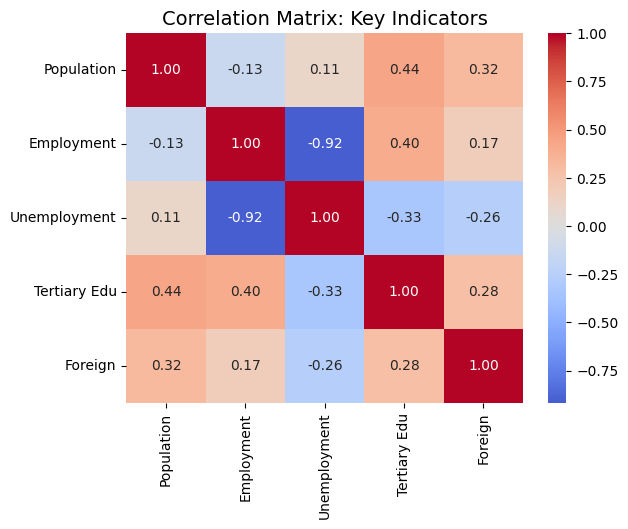

In [26]:

print("Strong negative correlation between employment and unemployment.\n      Tertiary education correlates positively with employment rate.")
cols = ['Population', 'Employment rate of persons aged 20 to 64, %', 
        'Share of unemployed persons in the labour force, %',
        'Persons with tertiary level qualifications, share of persons aged 15 or over, %',
        'Foreign citizens, %']

corr_df = mun[cols].apply(lambda x: pd.to_numeric(x, errors='coerce'))
corr_df.columns = ['Population', 'Employment', 'Unemployment', 'Tertiary Edu', 'Foreign']

sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Key Indicators', fontsize=14)

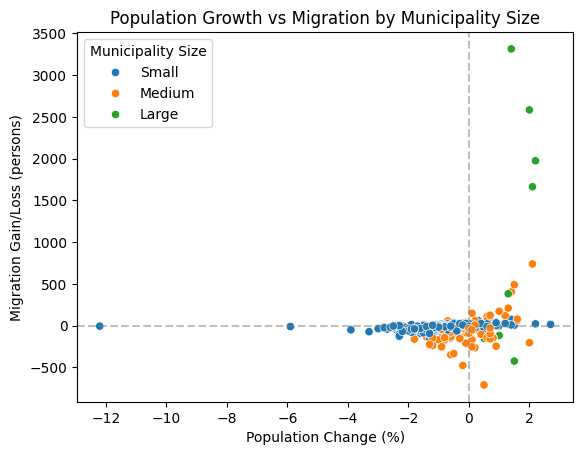

In [39]:

sns.scatterplot(data=mun, 
                x='Pop_change',
                y='Migration',
                hue='Size')
plt.xlabel('Population Change (%)')
plt.ylabel('Migration Gain/Loss (persons)')
plt.title('Population Growth vs Migration by Municipality Size')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.legend(title='Municipality Size')